# 🤪 Conditional WGAN-GP on CelebA Faces - Train

In this notebook, we'll walk through the steps required to train your own Conditional GAN on the CelebA faces dataset

The code has been adapted from the excellent [CGAN tutorial](https://keras.io/examples/generative/conditional_gan/) created by Sayak Paul, available on the Keras website.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import os

import tensorflow as tf
from tensorflow.keras import (
    layers,
    models,
    callbacks,
    utils,
    metrics,
    optimizers,
)

# Configure GPU - allow memory growth to avoid OOM
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs available: {[g.name for g in gpus]}")
else:
    print("No GPU found, training will run on CPU")

GPUs available: ['/physical_device:GPU:0', '/physical_device:GPU:1']


## 0. Parameters <a name="parameters"></a>

In [2]:
IMAGE_SIZE = 64
CHANNELS = 3
CLASSES = 2
BATCH_SIZE = 128
Z_DIM = 32
LEARNING_RATE = 0.00005
ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.999
EPOCHS = 20
CRITIC_STEPS = 3
GP_WEIGHT = 10.0
LOAD_MODEL = False
ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.9
LABEL = "Blond_Hair"

In [3]:
import matplotlib.pyplot as plt

# Helper functions (replacing notebooks.utils)
def display(images, n=10, save_to=None, cmap=None):
    n = min(n, len(images))
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2))
    if n == 1:
        axes = [axes]
    for i in range(n):
        img = images[i]
        img = np.clip(img, 0, 255) if img.max() > 1 else np.clip((img + 1) / 2, 0, 1)
        axes[i].imshow(img, cmap=cmap)
        axes[i].axis("off")
    if save_to:
        os.makedirs(os.path.dirname(save_to), exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
        print(f"Saved to {save_to}")
    plt.show()
    plt.close()

def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        return batch[0].numpy()
    return batch.numpy()

# --- Data paths ---
DATA_DIR = os.path.join(os.getcwd(), "Dataset")
IMG_DIR = os.path.join(DATA_DIR, "archive", "img_align_celeba", "img_align_celeba")
ATTR_CSV = os.path.join(DATA_DIR, "list_attr_celeba.csv", "list_attr_celeba.csv")

# Verify dataset exists
num_images = len(os.listdir(IMG_DIR)) if os.path.isdir(IMG_DIR) else 0
print(f"Image directory: {IMG_DIR}")
print(f"Attributes CSV: {ATTR_CSV}")
print(f"Number of images found: {num_images}")
assert num_images > 0, f"No images found in {IMG_DIR}!"
assert os.path.exists(ATTR_CSV), f"Attributes CSV not found at {ATTR_CSV}!"

Image directory: d:\GenAIWithLLM\Residency\Project1\Dataset\archive\img_align_celeba\img_align_celeba
Attributes CSV: d:\GenAIWithLLM\Residency\Project1\Dataset\list_attr_celeba.csv\list_attr_celeba.csv
Number of images found: 201311


## 1. Prepare the data <a name="prepare"></a>

In [4]:
# Load the label dataset
# Kaggle CelebA CSV has first row as count, then space-separated columns
with open(ATTR_CSV, 'r') as f:
    first_line = f.readline().strip()

# If first line is a number (Kaggle format), skip it and use whitespace separator
if first_line.isdigit():
    attributes = pd.read_csv(ATTR_CSV, sep=r'\s+', skiprows=1)
else:
    attributes = pd.read_csv(ATTR_CSV)

print(f"Attributes shape: {attributes.shape}")
print(attributes.columns.tolist()[:5], "...")
attributes.head()

Attributes shape: (202599, 41)
['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes'] ...


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [5]:
# Load the data - filter to only images that exist on disk
existing_images = sorted(os.listdir(IMG_DIR))
print(f"Images on disk: {len(existing_images)}, Rows in CSV: {len(attributes)}")

# Build a lookup from image_id to label
attributes_indexed = attributes.set_index("image_id")
int_labels = []
for img_name in existing_images:
    if img_name in attributes_indexed.index:
        val = attributes_indexed.loc[img_name, LABEL]
        int_labels.append(1 if val == 1 else 0)
    else:
        int_labels.append(0)  # default for missing entries

print(f"Matched labels: {len(int_labels)}, Positive: {sum(int_labels)}, Negative: {len(int_labels) - sum(int_labels)}")

Images on disk: 201311, Rows in CSV: 202599
Matched labels: 201311, Positive: 29790, Negative: 171521


In [6]:
train_data = utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "archive", "img_align_celeba"),
    labels=int_labels,
    color_mode="rgb",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    interpolation="bilinear",
)


Found 201311 files belonging to 1 classes.


In [7]:
# Preprocess the data
def preprocess(img):
    """
    Normalize and reshape the images
    """
    img = (tf.cast(img, "float32") - 127.5) / 127.5
    return img


train = train_data.map(
    lambda x, y: (preprocess(x), tf.one_hot(y, depth=CLASSES))
).repeat()  # repeat infinitely to support steps_per_epoch


In [8]:
# Show some faces from the training set
train_sample = sample_batch(train)

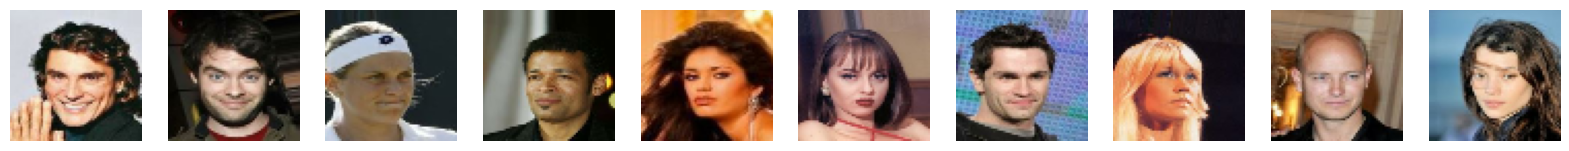

In [9]:
display(train_sample, cmap=None)

## 2. Build the GAN <a name="build"></a>

In [10]:
critic_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
label_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CLASSES))
x = layers.Concatenate(axis=-1)([critic_input, label_input])
x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv2D(1, kernel_size=4, strides=1, padding="valid")(x)
critic_output = layers.Flatten()(x)

critic = models.Model([critic_input, label_input], critic_output)
critic.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 64, 64, 3)]  0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 64, 64, 2)]  0           []                               
                                                                                                  
 concatenate (Concatenate)      (None, 64, 64, 5)    0           ['input_1[0][0]',                
                                                                  'input_2[0][0]']                
                                                                                                  
 conv2d (Conv2D)                (None, 32, 32, 64)   5184        ['concatenate[0][0]']        

In [11]:
generator_input = layers.Input(shape=(Z_DIM,))
label_input = layers.Input(shape=(CLASSES,))
x = layers.Concatenate(axis=-1)([generator_input, label_input])
x = layers.Reshape((1, 1, Z_DIM + CLASSES))(x)
x = layers.Conv2DTranspose(
    128, kernel_size=4, strides=1, padding="valid", use_bias=False
)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2DTranspose(
    128, kernel_size=4, strides=2, padding="same", use_bias=False
)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2DTranspose(
    128, kernel_size=4, strides=2, padding="same", use_bias=False
)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2DTranspose(
    64, kernel_size=4, strides=2, padding="same", use_bias=False
)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
generator_output = layers.Conv2DTranspose(
    CHANNELS, kernel_size=4, strides=2, padding="same", activation="tanh"
)(x)
generator = models.Model([generator_input, label_input], generator_output)
generator.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 32)]         0           []                               
                                                                                                  
 input_4 (InputLayer)           [(None, 2)]          0           []                               
                                                                                                  
 concatenate_1 (Concatenate)    (None, 34)           0           ['input_3[0][0]',                
                                                                  'input_4[0][0]']                
                                                                                                  
 reshape (Reshape)              (None, 1, 1, 34)     0           ['concatenate_1[0][0]']    

In [12]:
class ConditionalWGAN(models.Model):
    def __init__(self, critic, generator, latent_dim, critic_steps, gp_weight):
        super(ConditionalWGAN, self).__init__()
        self.critic = critic
        self.generator = generator
        self.latent_dim = latent_dim
        self.critic_steps = critic_steps
        self.gp_weight = gp_weight

    def compile(self, c_optimizer, g_optimizer):
        super(ConditionalWGAN, self).compile()
        self.c_optimizer = c_optimizer
        self.g_optimizer = g_optimizer
        self.c_wass_loss_metric = metrics.Mean(name="c_wass_loss")
        self.c_gp_metric = metrics.Mean(name="c_gp")
        self.c_loss_metric = metrics.Mean(name="c_loss")
        self.g_loss_metric = metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [
            self.c_loss_metric,
            self.c_wass_loss_metric,
            self.c_gp_metric,
            self.g_loss_metric,
        ]

    def gradient_penalty(
        self, batch_size, real_images, fake_images, image_one_hot_labels
    ):
        alpha = tf.random.normal([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = fake_images - real_images
        interpolated = real_images + alpha * diff

        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            pred = self.critic(
                [interpolated, image_one_hot_labels], training=True
            )

        grads = gp_tape.gradient(pred, [interpolated])[0]
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    def train_step(self, data):
        real_images, one_hot_labels = data

        image_one_hot_labels = one_hot_labels[:, None, None, :]
        image_one_hot_labels = tf.repeat(
            image_one_hot_labels, repeats=IMAGE_SIZE, axis=1
        )
        image_one_hot_labels = tf.repeat(
            image_one_hot_labels, repeats=IMAGE_SIZE, axis=2
        )

        batch_size = tf.shape(real_images)[0]

        for i in range(self.critic_steps):
            random_latent_vectors = tf.random.normal(
                shape=(batch_size, self.latent_dim)
            )

            with tf.GradientTape() as tape:
                fake_images = self.generator(
                    [random_latent_vectors, one_hot_labels], training=True
                )

                fake_predictions = self.critic(
                    [fake_images, image_one_hot_labels], training=True
                )
                real_predictions = self.critic(
                    [real_images, image_one_hot_labels], training=True
                )

                c_wass_loss = tf.reduce_mean(fake_predictions) - tf.reduce_mean(
                    real_predictions
                )
                c_gp = self.gradient_penalty(
                    batch_size, real_images, fake_images, image_one_hot_labels
                )
                c_loss = c_wass_loss + c_gp * self.gp_weight

            c_gradient = tape.gradient(c_loss, self.critic.trainable_variables)
            self.c_optimizer.apply_gradients(
                zip(c_gradient, self.critic.trainable_variables)
            )

        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim)
        )

        with tf.GradientTape() as tape:
            fake_images = self.generator(
                [random_latent_vectors, one_hot_labels], training=True
            )
            fake_predictions = self.critic(
                [fake_images, image_one_hot_labels], training=True
            )
            g_loss = -tf.reduce_mean(fake_predictions)

        gen_gradient = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(
            zip(gen_gradient, self.generator.trainable_variables)
        )

        self.c_loss_metric.update_state(c_loss)
        self.c_wass_loss_metric.update_state(c_wass_loss)
        self.c_gp_metric.update_state(c_gp)
        self.g_loss_metric.update_state(g_loss)

        return {m.name: m.result() for m in self.metrics}

In [13]:
# Create a GAN
cgan = ConditionalWGAN(
    critic=critic,
    generator=generator,
    latent_dim=Z_DIM,
    critic_steps=CRITIC_STEPS,
    gp_weight=GP_WEIGHT,
)

In [14]:
if LOAD_MODEL:
    cgan.load_weights("./checkpoint/checkpoint.ckpt")

## 3. Train the GAN <a name="train"></a>

In [15]:
# Compile the GAN
cgan.compile(
    c_optimizer=optimizers.Adam(
        learning_rate=LEARNING_RATE, beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2
    ),
    g_optimizer=optimizers.Adam(
        learning_rate=LEARNING_RATE, beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2
    ),
)

In [16]:
# Create a model save checkpoint
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoint/checkpoint.ckpt",
    save_weights_only=True,
    save_freq="epoch",
    verbose=0,
)

tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img, latent_dim, every_n_epochs=100):
        self.num_img = num_img
        self.latent_dim = latent_dim
        self.every_n_epochs = every_n_epochs

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n_epochs != 0:
            return

        random_latent_vectors = tf.random.normal(
            shape=(self.num_img, self.latent_dim)
        )
        # 0 label
        zero_label = np.repeat([[1, 0]], self.num_img, axis=0)
        generated_images = self.model.generator(
            [random_latent_vectors, zero_label]
        )
        generated_images = generated_images * 127.5 + 127.5
        generated_images = generated_images.numpy()
        display(
            generated_images,
            save_to="./output/generated_img_%03d_label_0.png" % (epoch),
            cmap=None,
        )

        # 1 label
        one_label = np.repeat([[0, 1]], self.num_img, axis=0)
        generated_images = self.model.generator(
            [random_latent_vectors, one_label]
        )
        generated_images = generated_images * 127.5 + 127.5
        generated_images = generated_images.numpy()
        display(
            generated_images,
            save_to="./output/generated_img_%03d_label_1.png" % (epoch),
            cmap=None,
        )

Epoch 1/2000
1/1 - 6s - c_loss: 7.2904 - c_wass_loss: -6.9949e-02 - c_gp: 0.7360 - g_loss: -3.9396e-02 - 6s/epoch - 6s/step
Epoch 2/2000
1/1 - 1s - c_loss: 7.1101 - c_wass_loss: -1.4973e-01 - c_gp: 0.7260 - g_loss: -8.2881e-03 - 546ms/epoch - 546ms/step
Epoch 3/2000
1/1 - 0s - c_loss: 6.8706 - c_wass_loss: -2.5752e-01 - c_gp: 0.7128 - g_loss: 0.0027 - 416ms/epoch - 416ms/step
Epoch 4/2000
1/1 - 0s - c_loss: 6.5638 - c_wass_loss: -3.7840e-01 - c_gp: 0.6942 - g_loss: 0.0609 - 417ms/epoch - 417ms/step
Epoch 5/2000
1/1 - 0s - c_loss: 6.2061 - c_wass_loss: -5.7189e-01 - c_gp: 0.6778 - g_loss: 0.1074 - 417ms/epoch - 417ms/step
Epoch 6/2000
1/1 - 0s - c_loss: 5.7576 - c_wass_loss: -7.9582e-01 - c_gp: 0.6553 - g_loss: 0.2090 - 404ms/epoch - 404ms/step
Epoch 7/2000
1/1 - 0s - c_loss: 5.1353 - c_wass_loss: -1.1450e+00 - c_gp: 0.6280 - g_loss: 0.2997 - 417ms/epoch - 417ms/step
Epoch 8/2000
1/1 - 0s - c_loss: 4.4295 - c_wass_loss: -1.6084e+00 - c_gp: 0.6038 - g_loss: 0.4055 - 416ms/epoch - 416ms/s

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.014183044..245.76569].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.027534485..245.8514].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4495926..247.44798].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4103546..247.00424].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.048599243..242.85963].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.1486053..248.14252].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.44496155

Saved to ./output/generated_img_099_label_0.png


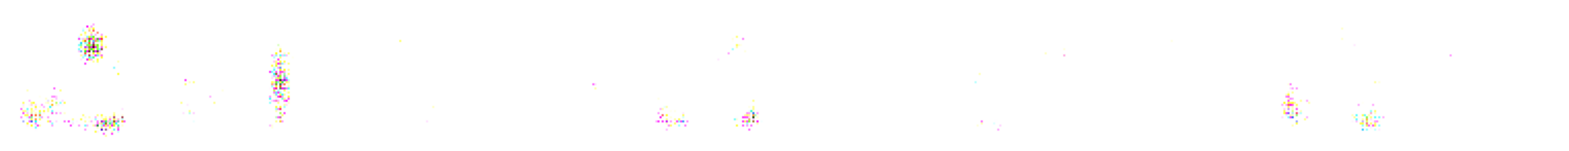

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.019195557..245.83278].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14654541..245.45496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.1344833..248.70657].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.1821594..246.98085].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.15836334..244.00793].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [5.862007..250.32278].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.3488312..2

Saved to ./output/generated_img_099_label_1.png


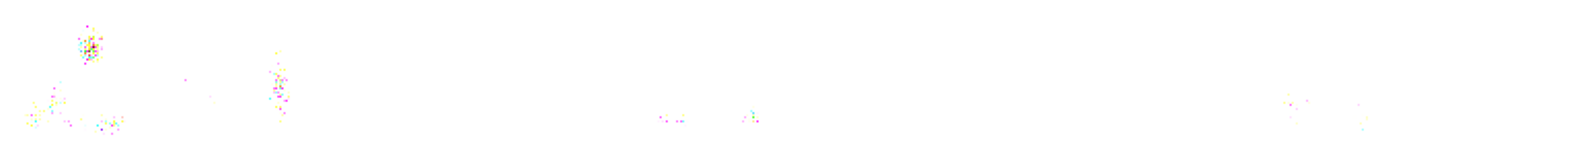

1/1 - 1s - c_loss: -5.1503e+01 - c_wass_loss: -7.7124e+01 - c_gp: 2.5621 - g_loss: 87.4953 - 804ms/epoch - 804ms/step
Epoch 101/2000
1/1 - 1s - c_loss: -5.6335e+01 - c_wass_loss: -7.8221e+01 - c_gp: 2.1886 - g_loss: 107.9030 - 515ms/epoch - 515ms/step
Epoch 102/2000
1/1 - 1s - c_loss: -5.0108e+01 - c_wass_loss: -7.2983e+01 - c_gp: 2.2874 - g_loss: 108.3409 - 530ms/epoch - 530ms/step
Epoch 103/2000
1/1 - 1s - c_loss: -3.8763e+01 - c_wass_loss: -5.9052e+01 - c_gp: 2.0288 - g_loss: 109.7314 - 528ms/epoch - 528ms/step
Epoch 104/2000
1/1 - 0s - c_loss: -4.4793e+01 - c_wass_loss: -6.4547e+01 - c_gp: 1.9754 - g_loss: 95.2809 - 499ms/epoch - 499ms/step
Epoch 105/2000
1/1 - 1s - c_loss: -5.1352e+01 - c_wass_loss: -7.0652e+01 - c_gp: 1.9299 - g_loss: 79.6382 - 569ms/epoch - 569ms/step
Epoch 106/2000
1/1 - 0s - c_loss: -4.5253e+01 - c_wass_loss: -6.5293e+01 - c_gp: 2.0040 - g_loss: 76.8160 - 427ms/epoch - 427ms/step
Epoch 107/2000
1/1 - 0s - c_loss: -4.4025e+01 - c_wass_loss: -6.2095e+01 - c_gp: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1990509..251.29536].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.7104263..244.34665].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [7.990074..247.90558].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.7293625..248.58487].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.346344..245.15765].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.054008484..251.21887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.364525..247.9

Saved to ./output/generated_img_199_label_0.png


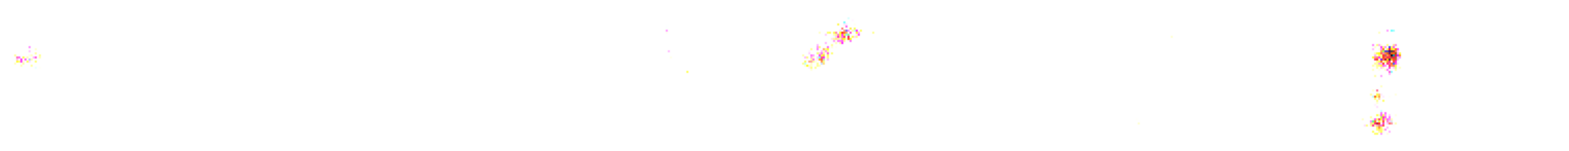

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5390396..250.63737].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.6096344..245.57468].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [13.214409..251.60294].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [7.492058..251.39426].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.39207458..249.4084].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.228302..251.18388].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [11.02919..250.464

Saved to ./output/generated_img_199_label_1.png


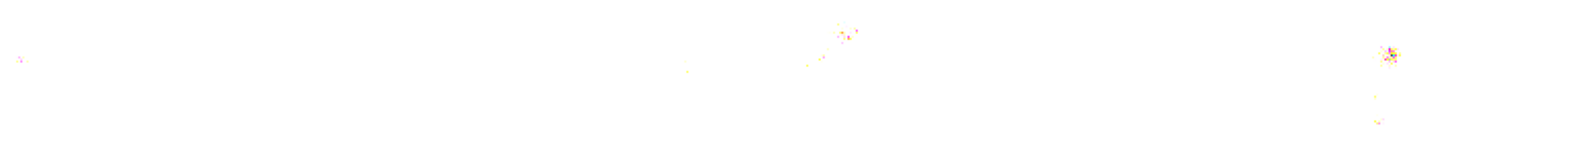

1/1 - 1s - c_loss: -1.0328e+01 - c_wass_loss: -1.1844e+01 - c_gp: 0.1517 - g_loss: 91.3750 - 1s/epoch - 1s/step
Epoch 201/2000
1/1 - 0s - c_loss: -8.3697e+00 - c_wass_loss: -9.9190e+00 - c_gp: 0.1549 - g_loss: 94.3187 - 424ms/epoch - 424ms/step
Epoch 202/2000
1/1 - 0s - c_loss: -3.3204e+00 - c_wass_loss: -4.9733e+00 - c_gp: 0.1653 - g_loss: 98.8620 - 405ms/epoch - 405ms/step
Epoch 203/2000
1/1 - 0s - c_loss: -8.3871e+00 - c_wass_loss: -1.0199e+01 - c_gp: 0.1812 - g_loss: 97.7023 - 431ms/epoch - 431ms/step
Epoch 204/2000
1/1 - 0s - c_loss: -6.8087e+00 - c_wass_loss: -8.5541e+00 - c_gp: 0.1745 - g_loss: 100.5144 - 459ms/epoch - 459ms/step
Epoch 205/2000
1/1 - 1s - c_loss: -2.5776e+00 - c_wass_loss: -4.1155e+00 - c_gp: 0.1538 - g_loss: 91.4156 - 530ms/epoch - 530ms/step
Epoch 206/2000
1/1 - 0s - c_loss: -9.8491e+00 - c_wass_loss: -1.1184e+01 - c_gp: 0.1335 - g_loss: 87.2755 - 435ms/epoch - 435ms/step
Epoch 207/2000
1/1 - 1s - c_loss: -8.8195e+00 - c_wass_loss: -1.0257e+01 - c_gp: 0.1438 -

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.148674..248.93137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.008834839..252.73694].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.47516632..250.41211].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0036468506..251.97028].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011245728..251.5091].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.7982254..251.7461].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01052093

Saved to ./output/generated_img_299_label_0.png


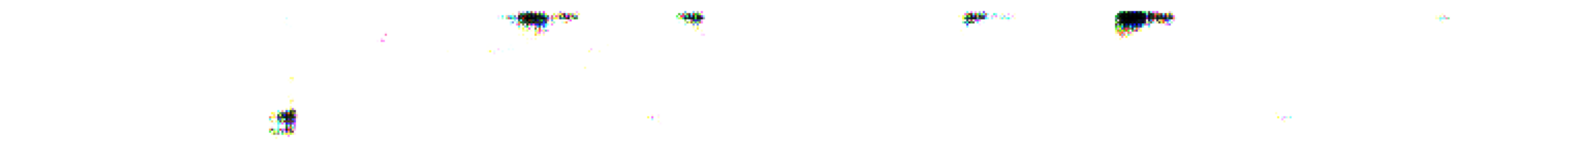

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.4786835..250.24783].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.03173828..252.7367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.3635559..251.55583].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.009338379..252.31941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.021217346..252.73419].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.989105..251.47466].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.024368286.

Saved to ./output/generated_img_299_label_1.png


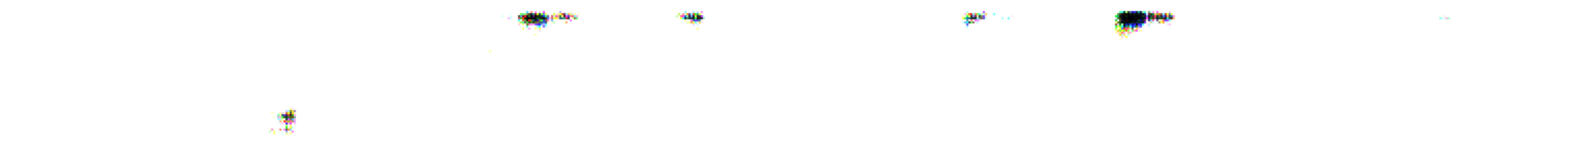

1/1 - 1s - c_loss: -9.9392e+00 - c_wass_loss: -1.1439e+01 - c_gp: 0.1499 - g_loss: 88.1186 - 843ms/epoch - 843ms/step
Epoch 301/2000
1/1 - 0s - c_loss: -4.4385e+00 - c_wass_loss: -5.9584e+00 - c_gp: 0.1520 - g_loss: 89.1659 - 495ms/epoch - 495ms/step
Epoch 302/2000
1/1 - 0s - c_loss: -7.6216e+00 - c_wass_loss: -9.1104e+00 - c_gp: 0.1489 - g_loss: 98.3124 - 487ms/epoch - 487ms/step
Epoch 303/2000
1/1 - 1s - c_loss: -4.2088e+00 - c_wass_loss: -5.6568e+00 - c_gp: 0.1448 - g_loss: 95.5412 - 524ms/epoch - 524ms/step
Epoch 304/2000
1/1 - 0s - c_loss: -1.1021e+01 - c_wass_loss: -1.2614e+01 - c_gp: 0.1594 - g_loss: 90.0464 - 481ms/epoch - 481ms/step
Epoch 305/2000
1/1 - 0s - c_loss: -1.1118e+01 - c_wass_loss: -1.2537e+01 - c_gp: 0.1419 - g_loss: 91.7661 - 470ms/epoch - 470ms/step
Epoch 306/2000
1/1 - 0s - c_loss: -5.5877e+00 - c_wass_loss: -7.3988e+00 - c_gp: 0.1811 - g_loss: 96.5524 - 472ms/epoch - 472ms/step
Epoch 307/2000
1/1 - 0s - c_loss: -5.0197e+00 - c_wass_loss: -6.6369e+00 - c_gp: 0.1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0448761..251.68338].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12601471..248.13335].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.006072998..253.3731].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14601898..252.44766].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.11349487..247.86859].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.7327347..253.9672].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.016342163.

Saved to ./output/generated_img_399_label_0.png


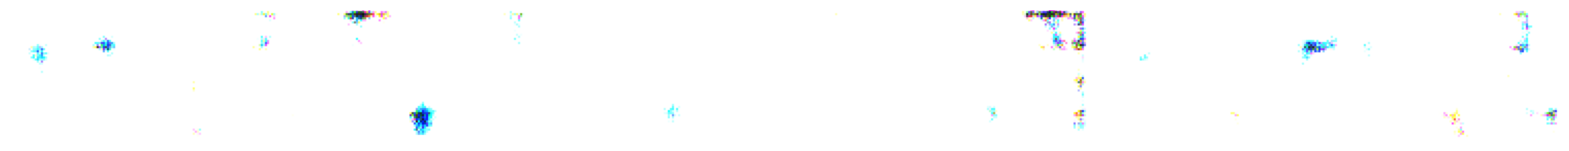

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.1638489..253.1409].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.26145172..251.92653].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.010177612..254.31003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.18093872..253.09023].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.345192..249.73483].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.7475662..254.52393].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.029212952..

Saved to ./output/generated_img_399_label_1.png


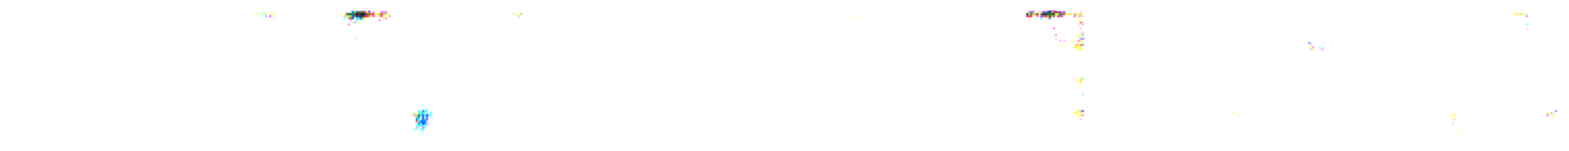

1/1 - 1s - c_loss: -4.9948e+00 - c_wass_loss: -6.0629e+00 - c_gp: 0.1068 - g_loss: 87.1305 - 854ms/epoch - 854ms/step
Epoch 401/2000
1/1 - 0s - c_loss: -6.0575e+00 - c_wass_loss: -7.0366e+00 - c_gp: 0.0979 - g_loss: 81.5648 - 469ms/epoch - 469ms/step
Epoch 402/2000
1/1 - 0s - c_loss: -9.2348e+00 - c_wass_loss: -1.0205e+01 - c_gp: 0.0970 - g_loss: 79.3215 - 476ms/epoch - 476ms/step
Epoch 403/2000
1/1 - 1s - c_loss: -1.9046e+00 - c_wass_loss: -2.8564e+00 - c_gp: 0.0952 - g_loss: 80.6325 - 512ms/epoch - 512ms/step
Epoch 404/2000
1/1 - 1s - c_loss: -4.7398e+00 - c_wass_loss: -5.5265e+00 - c_gp: 0.0787 - g_loss: 78.5614 - 534ms/epoch - 534ms/step
Epoch 405/2000
1/1 - 0s - c_loss: -5.5777e+00 - c_wass_loss: -6.4706e+00 - c_gp: 0.0893 - g_loss: 73.2792 - 454ms/epoch - 454ms/step
Epoch 406/2000
1/1 - 0s - c_loss: -3.5605e+00 - c_wass_loss: -4.4507e+00 - c_gp: 0.0890 - g_loss: 72.9800 - 410ms/epoch - 410ms/step
Epoch 407/2000
1/1 - 0s - c_loss: -1.0915e+01 - c_wass_loss: -1.1707e+01 - c_gp: 0.0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.22402954..248.24234].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.63009644..243.08087].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.22135925..253.8924].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.034347534..254.573].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.15119171..253.05864].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.13285065..247.66629].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.009262085

Saved to ./output/generated_img_499_label_0.png


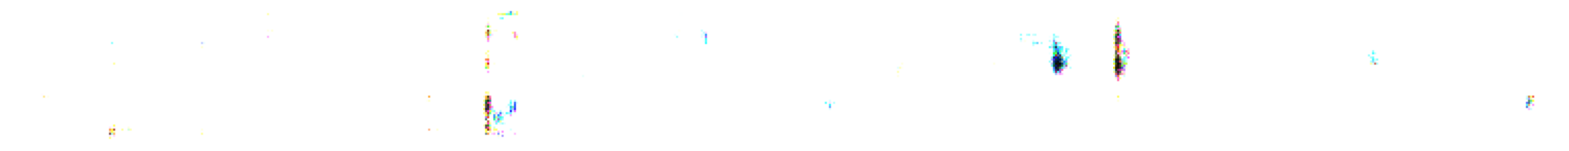

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.49585724..249.33005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.5005112..245.92426].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.0643692..253.67326].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06711578..254.4675].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.4372482..253.17998].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.8270416..251.76791].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.19047546..25

Saved to ./output/generated_img_499_label_1.png


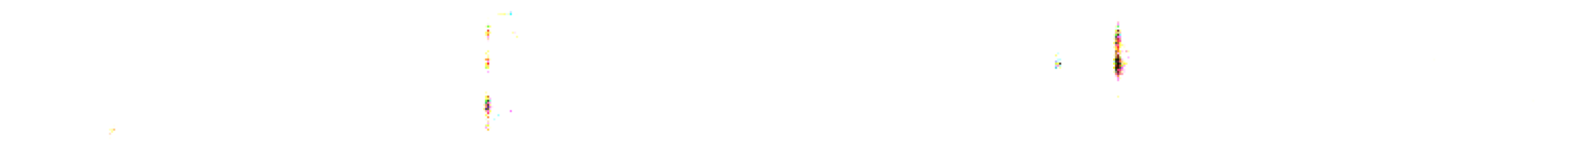

1/1 - 1s - c_loss: -5.7041e+00 - c_wass_loss: -6.4815e+00 - c_gp: 0.0777 - g_loss: 98.2596 - 812ms/epoch - 812ms/step
Epoch 501/2000
1/1 - 0s - c_loss: -2.3691e+00 - c_wass_loss: -3.0912e+00 - c_gp: 0.0722 - g_loss: 103.6083 - 469ms/epoch - 469ms/step
Epoch 502/2000
1/1 - 0s - c_loss: -4.6968e+00 - c_wass_loss: -5.2929e+00 - c_gp: 0.0596 - g_loss: 108.2586 - 484ms/epoch - 484ms/step
Epoch 503/2000
1/1 - 0s - c_loss: -8.5553e+00 - c_wass_loss: -9.2149e+00 - c_gp: 0.0660 - g_loss: 108.4132 - 469ms/epoch - 469ms/step
Epoch 504/2000
1/1 - 1s - c_loss: -5.4037e+00 - c_wass_loss: -6.1513e+00 - c_gp: 0.0748 - g_loss: 106.0244 - 592ms/epoch - 592ms/step
Epoch 505/2000
1/1 - 1s - c_loss: -7.9527e+00 - c_wass_loss: -8.7249e+00 - c_gp: 0.0772 - g_loss: 106.1978 - 511ms/epoch - 511ms/step
Epoch 506/2000
1/1 - 1s - c_loss: -7.9981e+00 - c_wass_loss: -8.9607e+00 - c_gp: 0.0963 - g_loss: 109.6843 - 530ms/epoch - 530ms/step
Epoch 507/2000
1/1 - 1s - c_loss: -1.1144e+01 - c_wass_loss: -1.1814e+01 - c_g

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.2275925..254.27826].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.004432678..252.98682].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.13973236..250.6064].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.76420593..253.21722].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.11042023..254.22421].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.1661987..252.96867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4081955..

Saved to ./output/generated_img_599_label_0.png


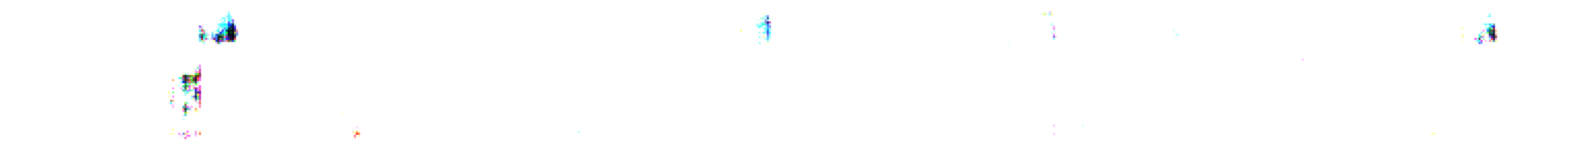

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [15.902351..254.36629].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.08190155..253.90015].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4941101..252.63509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.163353..252.68106].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.32203674..254.40527].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.9610443..253.60934].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.9968872..254

Saved to ./output/generated_img_599_label_1.png


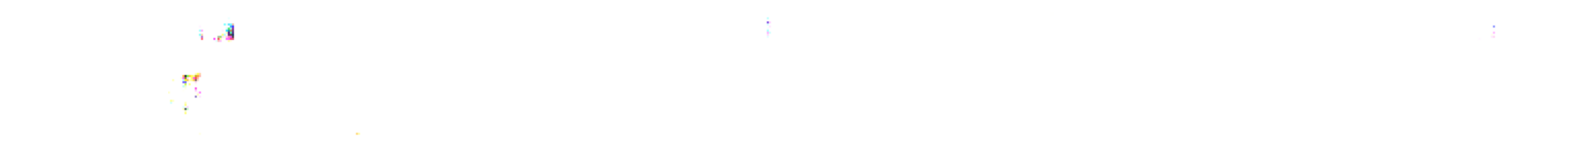

1/1 - 1s - c_loss: -1.9502e+00 - c_wass_loss: -2.5776e+00 - c_gp: 0.0627 - g_loss: 64.5472 - 769ms/epoch - 769ms/step
Epoch 601/2000
1/1 - 1s - c_loss: -1.7619e+00 - c_wass_loss: -2.2457e+00 - c_gp: 0.0484 - g_loss: 60.4868 - 601ms/epoch - 601ms/step
Epoch 602/2000
1/1 - 0s - c_loss: -1.6068e+00 - c_wass_loss: -2.1678e+00 - c_gp: 0.0561 - g_loss: 57.7279 - 411ms/epoch - 411ms/step
Epoch 603/2000
1/1 - 0s - c_loss: -4.4870e+00 - c_wass_loss: -5.0836e+00 - c_gp: 0.0597 - g_loss: 50.6243 - 429ms/epoch - 429ms/step
Epoch 604/2000
1/1 - 0s - c_loss: -1.0182e+01 - c_wass_loss: -1.0860e+01 - c_gp: 0.0677 - g_loss: 56.1802 - 417ms/epoch - 417ms/step
Epoch 605/2000
1/1 - 0s - c_loss: -7.4525e+00 - c_wass_loss: -8.1964e+00 - c_gp: 0.0744 - g_loss: 50.3983 - 417ms/epoch - 417ms/step
Epoch 606/2000
1/1 - 0s - c_loss: -1.1593e+01 - c_wass_loss: -1.2335e+01 - c_gp: 0.0742 - g_loss: 50.7477 - 419ms/epoch - 419ms/step
Epoch 607/2000
1/1 - 0s - c_loss: -1.2060e+01 - c_wass_loss: -1.3260e+01 - c_gp: 0.1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.9597244..249.3928].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.4152069..252.5637].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.35536194..254.52084].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.4233627..252.35257].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5022812..253.96939].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.057647705..254.08463].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.7209167..249

Saved to ./output/generated_img_699_label_0.png


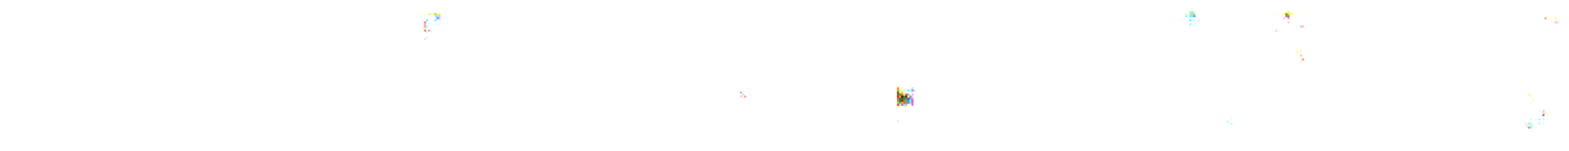

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.489937..252.43608].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [12.220764..253.34615].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.6886749..254.64868].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.0578384..252.54431].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.1817932..254.33507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.49302673..253.7945].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [6.82164..249.852

Saved to ./output/generated_img_699_label_1.png


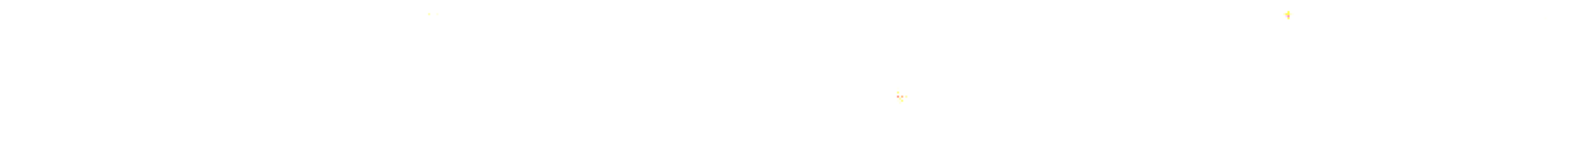

1/1 - 1s - c_loss: -8.0692e+00 - c_wass_loss: -8.6789e+00 - c_gp: 0.0610 - g_loss: 12.8363 - 724ms/epoch - 724ms/step
Epoch 701/2000
1/1 - 0s - c_loss: -1.0175e+01 - c_wass_loss: -1.0886e+01 - c_gp: 0.0711 - g_loss: 12.2994 - 403ms/epoch - 403ms/step
Epoch 702/2000
1/1 - 0s - c_loss: -4.9669e+00 - c_wass_loss: -5.6923e+00 - c_gp: 0.0725 - g_loss: 10.8394 - 410ms/epoch - 410ms/step
Epoch 703/2000
1/1 - 0s - c_loss: -9.8373e+00 - c_wass_loss: -1.0497e+01 - c_gp: 0.0660 - g_loss: 17.3006 - 413ms/epoch - 413ms/step
Epoch 704/2000
1/1 - 0s - c_loss: -8.1867e+00 - c_wass_loss: -8.9685e+00 - c_gp: 0.0782 - g_loss: 15.0118 - 455ms/epoch - 455ms/step
Epoch 705/2000
1/1 - 0s - c_loss: -9.0586e+00 - c_wass_loss: -9.7793e+00 - c_gp: 0.0721 - g_loss: 19.7477 - 418ms/epoch - 418ms/step
Epoch 706/2000
1/1 - 0s - c_loss: -9.2163e+00 - c_wass_loss: -1.0047e+01 - c_gp: 0.0830 - g_loss: 20.4625 - 421ms/epoch - 421ms/step
Epoch 707/2000
1/1 - 0s - c_loss: -8.6152e+00 - c_wass_loss: -9.4021e+00 - c_gp: 0.0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.02722168..252.4328].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1349945..251.56802].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.5243683..248.53354].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.042060852..253.10104].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.19223785..252.4722].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.04018402..252.96478].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.018333435.

Saved to ./output/generated_img_799_label_0.png


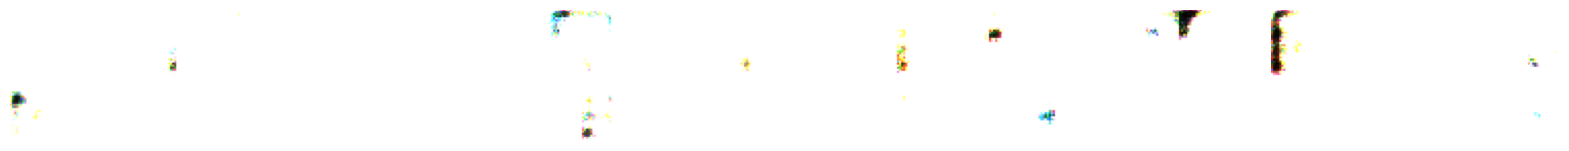

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10889435..251.53333].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.18959808..251.71738].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [5.854347..249.24458].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.111763..253.24792].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.26754..253.34824].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3810959..253.45966].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1203537..254.13

Saved to ./output/generated_img_799_label_1.png


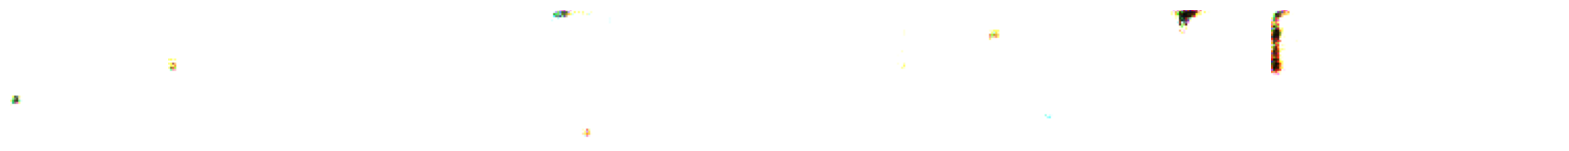

1/1 - 1s - c_loss: -8.9678e+00 - c_wass_loss: -9.3638e+00 - c_gp: 0.0396 - g_loss: 7.4627 - 759ms/epoch - 759ms/step
Epoch 801/2000
1/1 - 0s - c_loss: -7.3557e+00 - c_wass_loss: -7.9886e+00 - c_gp: 0.0633 - g_loss: 9.1103 - 416ms/epoch - 416ms/step
Epoch 802/2000
1/1 - 0s - c_loss: -9.6094e+00 - c_wass_loss: -1.0292e+01 - c_gp: 0.0682 - g_loss: 8.8582 - 406ms/epoch - 406ms/step
Epoch 803/2000
1/1 - 0s - c_loss: -7.3087e+00 - c_wass_loss: -8.0708e+00 - c_gp: 0.0762 - g_loss: 7.3421 - 404ms/epoch - 404ms/step
Epoch 804/2000
1/1 - 0s - c_loss: -8.6544e+00 - c_wass_loss: -9.2704e+00 - c_gp: 0.0616 - g_loss: -8.4579e-01 - 403ms/epoch - 403ms/step
Epoch 805/2000
1/1 - 0s - c_loss: -8.3913e+00 - c_wass_loss: -9.0999e+00 - c_gp: 0.0709 - g_loss: 0.9609 - 392ms/epoch - 392ms/step
Epoch 806/2000
1/1 - 0s - c_loss: -5.6235e+00 - c_wass_loss: -6.3618e+00 - c_gp: 0.0738 - g_loss: -4.2714e+00 - 396ms/epoch - 396ms/step
Epoch 807/2000
1/1 - 0s - c_loss: -3.0473e+00 - c_wass_loss: -3.7339e+00 - c_gp: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.75675964..253.23868].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1424942..252.80432].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.05609131..252.76332].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.027626038..252.66641].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.111091614..249.8678].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.008872986..248.94427].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.174324

Saved to ./output/generated_img_899_label_0.png


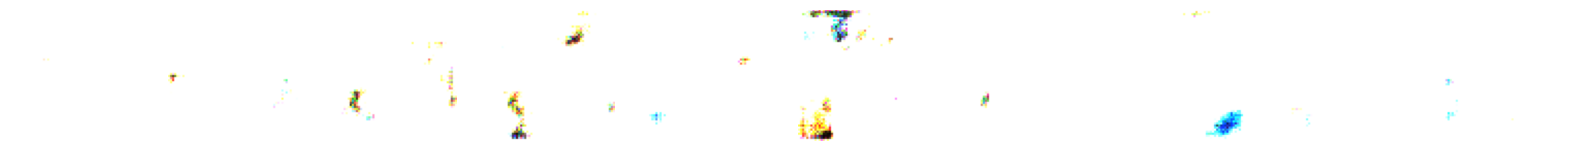

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.0646973..252.93207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.28204346..253.4224].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.58525085..253.35574].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.17597961..253.15097].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.5535965..250.43275].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.03414917..252.49045].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.0284653..2

Saved to ./output/generated_img_899_label_1.png


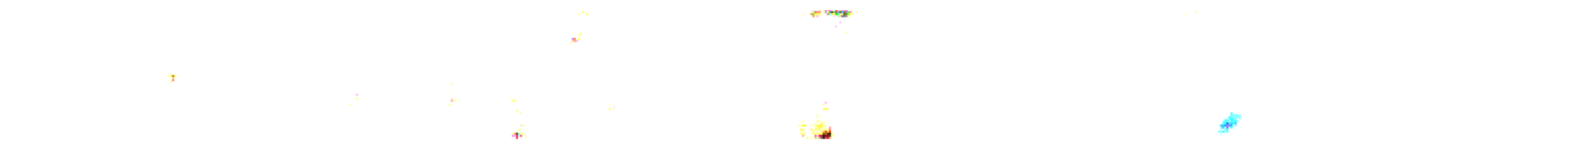

1/1 - 1s - c_loss: -9.5303e+00 - c_wass_loss: -1.0671e+01 - c_gp: 0.1141 - g_loss: -1.3237e+01 - 986ms/epoch - 986ms/step
Epoch 901/2000
1/1 - 0s - c_loss: -4.8291e+00 - c_wass_loss: -5.7849e+00 - c_gp: 0.0956 - g_loss: -1.2188e+01 - 424ms/epoch - 424ms/step
Epoch 902/2000
1/1 - 0s - c_loss: -4.2495e+00 - c_wass_loss: -5.0589e+00 - c_gp: 0.0809 - g_loss: -8.0202e+00 - 419ms/epoch - 419ms/step
Epoch 903/2000
1/1 - 0s - c_loss: -3.3672e+00 - c_wass_loss: -4.1144e+00 - c_gp: 0.0747 - g_loss: -8.1114e+00 - 426ms/epoch - 426ms/step
Epoch 904/2000
1/1 - 0s - c_loss: -7.9627e+00 - c_wass_loss: -8.6696e+00 - c_gp: 0.0707 - g_loss: 1.3873 - 434ms/epoch - 434ms/step
Epoch 905/2000
1/1 - 0s - c_loss: -6.2283e+00 - c_wass_loss: -6.8935e+00 - c_gp: 0.0665 - g_loss: -6.6013e+00 - 455ms/epoch - 455ms/step
Epoch 906/2000
1/1 - 0s - c_loss: -9.9024e+00 - c_wass_loss: -1.0521e+01 - c_gp: 0.0619 - g_loss: -5.4350e+00 - 437ms/epoch - 437ms/step
Epoch 907/2000
1/1 - 0s - c_loss: -5.3398e+00 - c_wass_loss: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.13747406..251.68951].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.020713806..254.59119].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [7.034561..250.73352].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.05735016..254.84674].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07233429..250.0375].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14905548..253.97313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14085388.

Saved to ./output/generated_img_999_label_0.png


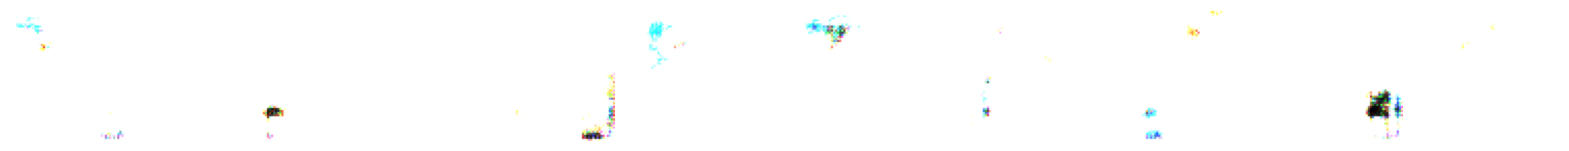

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4362259..252.73373].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.64011383..253.99924].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [27.611427..250.87418].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.20506287..254.75418].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2875061..251.46771].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.562088..254.01921].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.2441635..253

Saved to ./output/generated_img_999_label_1.png


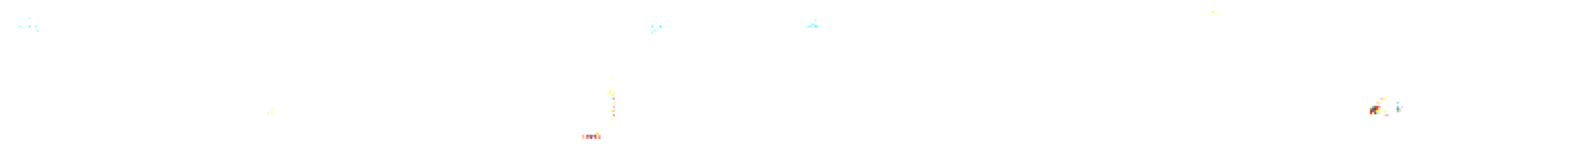

1/1 - 1s - c_loss: -3.3041e+00 - c_wass_loss: -4.2953e+00 - c_gp: 0.0991 - g_loss: -2.3431e+01 - 721ms/epoch - 721ms/step
Epoch 1001/2000
1/1 - 0s - c_loss: -3.7368e+00 - c_wass_loss: -4.8183e+00 - c_gp: 0.1081 - g_loss: -2.0269e+01 - 417ms/epoch - 417ms/step
Epoch 1002/2000
1/1 - 0s - c_loss: -6.1128e+00 - c_wass_loss: -7.2291e+00 - c_gp: 0.1116 - g_loss: -2.0302e+01 - 422ms/epoch - 422ms/step
Epoch 1003/2000
1/1 - 0s - c_loss: -7.9535e+00 - c_wass_loss: -9.1299e+00 - c_gp: 0.1176 - g_loss: -1.5635e+01 - 441ms/epoch - 441ms/step
Epoch 1004/2000
1/1 - 0s - c_loss: -8.1409e+00 - c_wass_loss: -9.2572e+00 - c_gp: 0.1116 - g_loss: -1.5239e+01 - 414ms/epoch - 414ms/step
Epoch 1005/2000
1/1 - 0s - c_loss: -7.5176e+00 - c_wass_loss: -8.5986e+00 - c_gp: 0.1081 - g_loss: -1.8304e+01 - 420ms/epoch - 420ms/step
Epoch 1006/2000
1/1 - 0s - c_loss: -5.9160e+00 - c_wass_loss: -6.9354e+00 - c_gp: 0.1019 - g_loss: -1.9613e+01 - 411ms/epoch - 411ms/step
Epoch 1007/2000
1/1 - 0s - c_loss: -5.8315e+00 - c

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.014961243..251.12434].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.021339417..252.54143].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.46801758..252.65222].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.47491455..254.13394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.1483688..251.79633].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.96800995..250.8162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.7266388

Saved to ./output/generated_img_1099_label_0.png


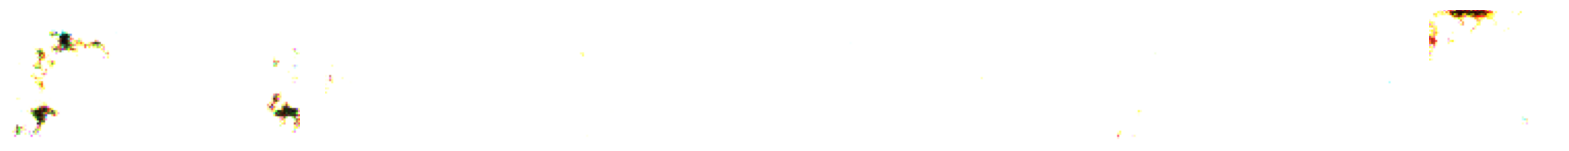

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.17793274..250.54163].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.265625..252.1214].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.9767151..252.44292].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.7561417..254.18668].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.8310165..251.13013].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.636734..250.42697].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.1783676..253.85

Saved to ./output/generated_img_1099_label_1.png


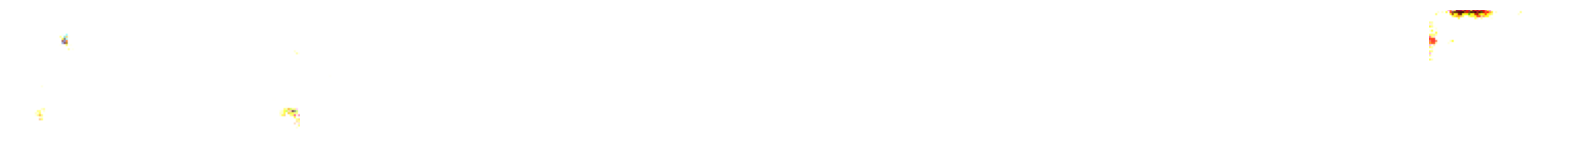

1/1 - 1s - c_loss: -8.8768e+00 - c_wass_loss: -9.5583e+00 - c_gp: 0.0681 - g_loss: -5.0544e+01 - 815ms/epoch - 815ms/step
Epoch 1101/2000
1/1 - 0s - c_loss: -8.3401e+00 - c_wass_loss: -9.1505e+00 - c_gp: 0.0810 - g_loss: -5.5496e+01 - 440ms/epoch - 440ms/step
Epoch 1102/2000
1/1 - 0s - c_loss: -6.5608e+00 - c_wass_loss: -7.4445e+00 - c_gp: 0.0884 - g_loss: -5.9373e+01 - 453ms/epoch - 453ms/step
Epoch 1103/2000
1/1 - 0s - c_loss: -6.5486e+00 - c_wass_loss: -7.5466e+00 - c_gp: 0.0998 - g_loss: -5.6474e+01 - 436ms/epoch - 436ms/step
Epoch 1104/2000
1/1 - 0s - c_loss: -5.9506e+00 - c_wass_loss: -7.0798e+00 - c_gp: 0.1129 - g_loss: -5.8895e+01 - 420ms/epoch - 420ms/step
Epoch 1105/2000
1/1 - 0s - c_loss: -8.3134e+00 - c_wass_loss: -9.3195e+00 - c_gp: 0.1006 - g_loss: -5.0474e+01 - 420ms/epoch - 420ms/step
Epoch 1106/2000
1/1 - 0s - c_loss: -1.1535e+01 - c_wass_loss: -1.2538e+01 - c_gp: 0.1003 - g_loss: -5.2828e+01 - 434ms/epoch - 434ms/step
Epoch 1107/2000
1/1 - 0s - c_loss: -9.6316e+00 - c

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.0322037..249.47076].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0002670288..254.23169].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.4502487..254.40329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.036598206..242.42703].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.118011475..250.66275].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.367897..253.56438].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4405288

Saved to ./output/generated_img_1199_label_0.png


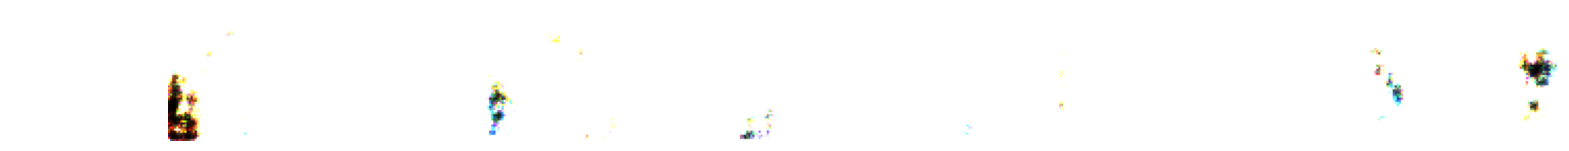

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.524933..250.29883].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.001335144..253.85056].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [8.408302..253.74687].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.59874725..244.2303].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.64517975..248.05246].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [32.226814..253.06526].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [5.194397..252.

Saved to ./output/generated_img_1199_label_1.png


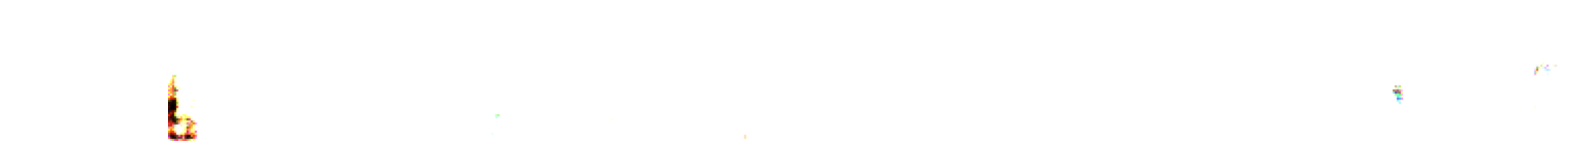

1/1 - 1s - c_loss: -6.4397e+00 - c_wass_loss: -6.9921e+00 - c_gp: 0.0552 - g_loss: -4.7515e+01 - 869ms/epoch - 869ms/step
Epoch 1201/2000
1/1 - 0s - c_loss: -2.4914e+00 - c_wass_loss: -2.9796e+00 - c_gp: 0.0488 - g_loss: -4.2371e+01 - 429ms/epoch - 429ms/step
Epoch 1202/2000
1/1 - 0s - c_loss: -7.1111e+00 - c_wass_loss: -7.6574e+00 - c_gp: 0.0546 - g_loss: -3.7377e+01 - 462ms/epoch - 462ms/step
Epoch 1203/2000
1/1 - 0s - c_loss: -4.8510e+00 - c_wass_loss: -5.4857e+00 - c_gp: 0.0635 - g_loss: -4.1257e+01 - 427ms/epoch - 427ms/step
Epoch 1204/2000
1/1 - 0s - c_loss: -1.1848e+01 - c_wass_loss: -1.2496e+01 - c_gp: 0.0648 - g_loss: -4.0219e+01 - 482ms/epoch - 482ms/step
Epoch 1205/2000
1/1 - 0s - c_loss: -7.1079e+00 - c_wass_loss: -7.8490e+00 - c_gp: 0.0741 - g_loss: -4.2517e+01 - 495ms/epoch - 495ms/step
Epoch 1206/2000
1/1 - 0s - c_loss: -4.8517e+00 - c_wass_loss: -5.6088e+00 - c_gp: 0.0757 - g_loss: -4.5337e+01 - 490ms/epoch - 490ms/step
Epoch 1207/2000
1/1 - 0s - c_loss: -4.6411e+00 - c

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.056381226..251.64471].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12184143..252.11188].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3320465..252.74979].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10354614..253.84358].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.86805725..246.9906].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.40245056..254.14862].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2577362.

Saved to ./output/generated_img_1299_label_0.png


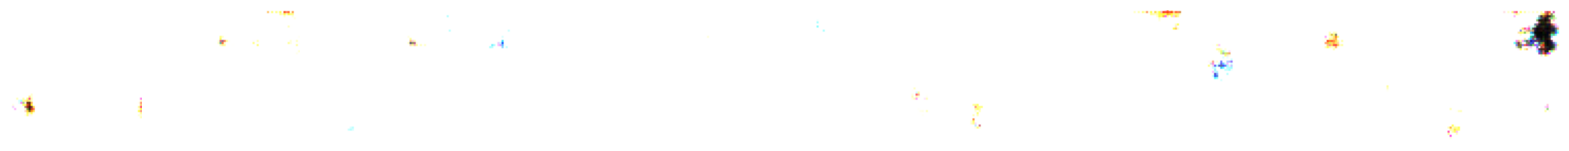

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.6106949..250.12381].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2541809..252.05545].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.194252..252.59499].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.1233978..252.60806].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [13.337555..248.55328].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.5338364..254.2537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.290451..252.414

Saved to ./output/generated_img_1299_label_1.png


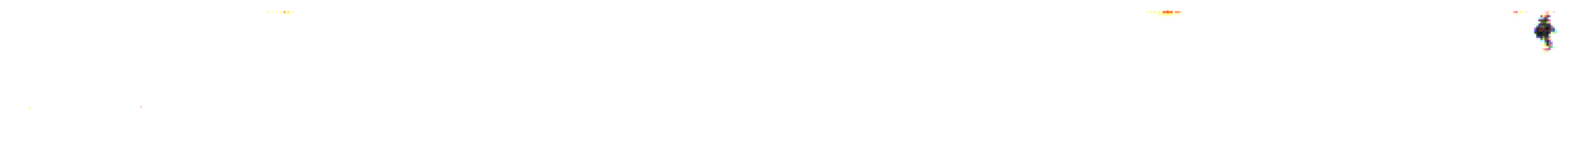

1/1 - 1s - c_loss: -5.3797e+00 - c_wass_loss: -6.0118e+00 - c_gp: 0.0632 - g_loss: -3.1150e+01 - 999ms/epoch - 999ms/step
Epoch 1301/2000
1/1 - 0s - c_loss: -4.5685e+00 - c_wass_loss: -5.2231e+00 - c_gp: 0.0655 - g_loss: -3.2175e+01 - 422ms/epoch - 422ms/step
Epoch 1302/2000
1/1 - 0s - c_loss: -5.6505e+00 - c_wass_loss: -6.3504e+00 - c_gp: 0.0700 - g_loss: -3.0582e+01 - 422ms/epoch - 422ms/step
Epoch 1303/2000
1/1 - 0s - c_loss: -7.8172e+00 - c_wass_loss: -8.4367e+00 - c_gp: 0.0619 - g_loss: -3.2997e+01 - 453ms/epoch - 453ms/step
Epoch 1304/2000
1/1 - 0s - c_loss: -5.4195e+00 - c_wass_loss: -6.0789e+00 - c_gp: 0.0659 - g_loss: -3.2608e+01 - 471ms/epoch - 471ms/step
Epoch 1305/2000
1/1 - 0s - c_loss: -1.0536e+01 - c_wass_loss: -1.1178e+01 - c_gp: 0.0641 - g_loss: -3.3482e+01 - 406ms/epoch - 406ms/step
Epoch 1306/2000
1/1 - 0s - c_loss: -7.0307e+00 - c_wass_loss: -7.7065e+00 - c_gp: 0.0676 - g_loss: -3.1124e+01 - 416ms/epoch - 416ms/step
Epoch 1307/2000
1/1 - 0s - c_loss: -6.6896e+00 - c

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.15177155..251.84137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.39697266..253.84763].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0025100708..254.19463].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.1558685..253.09958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.028266907..251.67114].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.7539444..254.87967].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.024322

Saved to ./output/generated_img_1399_label_0.png


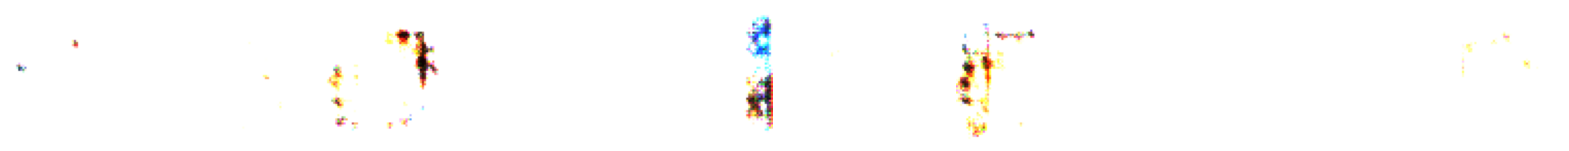

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.1844482..251.84798].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.6689377..253.87747].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2040329..254.44571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.1292114..252.20886].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.09618378..250.93613].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [6.219734..254.6861].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.50746155..254.

Saved to ./output/generated_img_1399_label_1.png


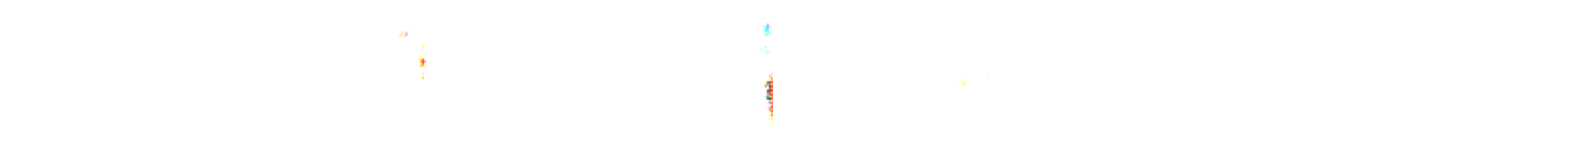

1/1 - 2s - c_loss: -5.4827e+00 - c_wass_loss: -6.0528e+00 - c_gp: 0.0570 - g_loss: -2.7748e+01 - 2s/epoch - 2s/step
Epoch 1401/2000
1/1 - 1s - c_loss: -9.2837e+00 - c_wass_loss: -9.9390e+00 - c_gp: 0.0655 - g_loss: -2.7966e+01 - 1s/epoch - 1s/step
Epoch 1402/2000
1/1 - 1s - c_loss: -1.6185e+00 - c_wass_loss: -2.2080e+00 - c_gp: 0.0589 - g_loss: -2.9949e+01 - 535ms/epoch - 535ms/step
Epoch 1403/2000
1/1 - 1s - c_loss: -5.3408e+00 - c_wass_loss: -5.9335e+00 - c_gp: 0.0593 - g_loss: -2.5382e+01 - 564ms/epoch - 564ms/step
Epoch 1404/2000
1/1 - 1s - c_loss: -4.7556e+00 - c_wass_loss: -5.3491e+00 - c_gp: 0.0594 - g_loss: -2.6053e+01 - 540ms/epoch - 540ms/step
Epoch 1405/2000
1/1 - 1s - c_loss: -9.7386e+00 - c_wass_loss: -1.0372e+01 - c_gp: 0.0633 - g_loss: -2.3879e+01 - 550ms/epoch - 550ms/step
Epoch 1406/2000
1/1 - 1s - c_loss: -4.0545e+00 - c_wass_loss: -4.7452e+00 - c_gp: 0.0691 - g_loss: -2.6348e+01 - 548ms/epoch - 548ms/step
Epoch 1407/2000
1/1 - 1s - c_loss: -7.5184e+00 - c_wass_loss: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.153267..250.07722].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.010070801..254.87236].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.27030182..254.97742].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01914978..253.85864].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.03501892..251.09796].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.2793274..249.54224].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.28996277.

Saved to ./output/generated_img_1499_label_0.png


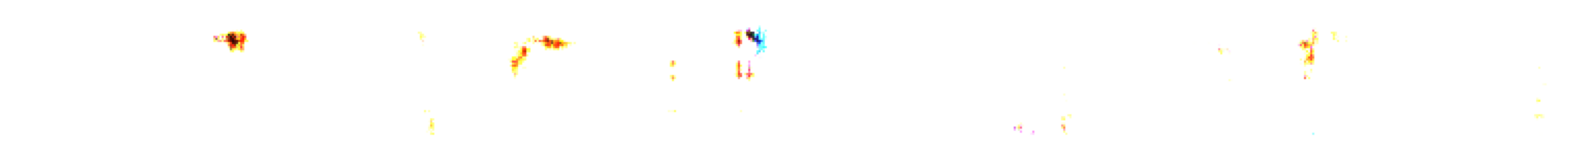

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [19.960472..249.83472].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.20375824..254.85286].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.8614273..254.96902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.3072586..253.29633].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.43534088..249.52576].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [22.414314..247.5387].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.7364349..248

Saved to ./output/generated_img_1499_label_1.png


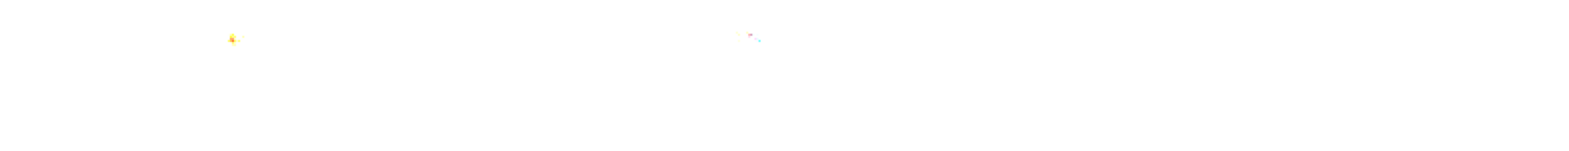

1/1 - 1s - c_loss: -7.8560e+00 - c_wass_loss: -8.5023e+00 - c_gp: 0.0646 - g_loss: -5.9938e+01 - 1s/epoch - 1s/step
Epoch 1501/2000
1/1 - 1s - c_loss: -2.9383e+00 - c_wass_loss: -3.6329e+00 - c_gp: 0.0695 - g_loss: -4.7878e+01 - 619ms/epoch - 619ms/step
Epoch 1502/2000
1/1 - 1s - c_loss: -1.0596e+01 - c_wass_loss: -1.1343e+01 - c_gp: 0.0747 - g_loss: -5.1166e+01 - 598ms/epoch - 598ms/step
Epoch 1503/2000
1/1 - 1s - c_loss: -7.7414e+00 - c_wass_loss: -8.4957e+00 - c_gp: 0.0754 - g_loss: -4.5846e+01 - 570ms/epoch - 570ms/step
Epoch 1504/2000
1/1 - 1s - c_loss: -2.8124e+00 - c_wass_loss: -3.4931e+00 - c_gp: 0.0681 - g_loss: -5.0173e+01 - 564ms/epoch - 564ms/step
Epoch 1505/2000
1/1 - 1s - c_loss: -5.9858e+00 - c_wass_loss: -6.6992e+00 - c_gp: 0.0713 - g_loss: -4.8096e+01 - 554ms/epoch - 554ms/step
Epoch 1506/2000
1/1 - 1s - c_loss: -3.6824e+00 - c_wass_loss: -4.3453e+00 - c_gp: 0.0663 - g_loss: -4.3322e+01 - 568ms/epoch - 568ms/step
Epoch 1507/2000
1/1 - 1s - c_loss: -6.2588e+00 - c_wass_

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.057434082..253.93207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [5.3469696..252.98831].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.6466141..250.87299].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0062026978..254.86322].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.02458191..254.97769].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [5.2467346..254.37967].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0014724

Saved to ./output/generated_img_1599_label_0.png


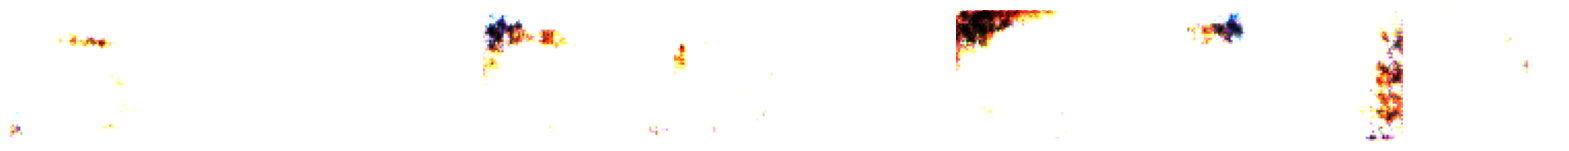

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.80228424..253.92432].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [21.17485..252.50388].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.319252..250.69556].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.027709961..254.86285].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.24108887..254.97623].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [10.003723..254.2236].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.004096985..2

Saved to ./output/generated_img_1599_label_1.png


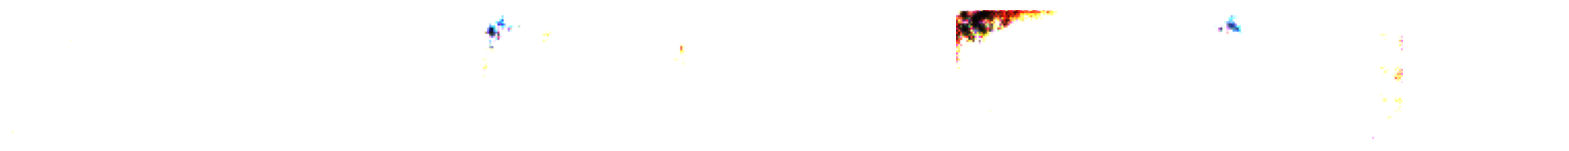

1/1 - 1s - c_loss: -9.2019e+00 - c_wass_loss: -9.6711e+00 - c_gp: 0.0469 - g_loss: -2.2245e+01 - 1s/epoch - 1s/step
Epoch 1601/2000
1/1 - 1s - c_loss: -2.1613e+00 - c_wass_loss: -2.7539e+00 - c_gp: 0.0593 - g_loss: -2.3370e+01 - 624ms/epoch - 624ms/step
Epoch 1602/2000
1/1 - 1s - c_loss: -1.1200e+00 - c_wass_loss: -1.6697e+00 - c_gp: 0.0550 - g_loss: -2.9348e+01 - 581ms/epoch - 581ms/step
Epoch 1603/2000
1/1 - 1s - c_loss: -1.0145e+01 - c_wass_loss: -1.0580e+01 - c_gp: 0.0435 - g_loss: -2.8153e+01 - 567ms/epoch - 567ms/step
Epoch 1604/2000
1/1 - 1s - c_loss: -4.0589e+00 - c_wass_loss: -4.5253e+00 - c_gp: 0.0466 - g_loss: -2.8576e+01 - 549ms/epoch - 549ms/step
Epoch 1605/2000
1/1 - 1s - c_loss: -5.9888e+00 - c_wass_loss: -6.5061e+00 - c_gp: 0.0517 - g_loss: -2.8396e+01 - 558ms/epoch - 558ms/step
Epoch 1606/2000
1/1 - 1s - c_loss: -7.9045e+00 - c_wass_loss: -8.4855e+00 - c_gp: 0.0581 - g_loss: -3.2939e+01 - 559ms/epoch - 559ms/step
Epoch 1607/2000
1/1 - 1s - c_loss: -2.8554e+00 - c_wass_

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0031280518..254.42792].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0001296997..246.23111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.5114212..253.20056].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.4620667..254.07741].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.045707703..248.74422].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.22968292..252.52722].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0184

Saved to ./output/generated_img_1699_label_0.png


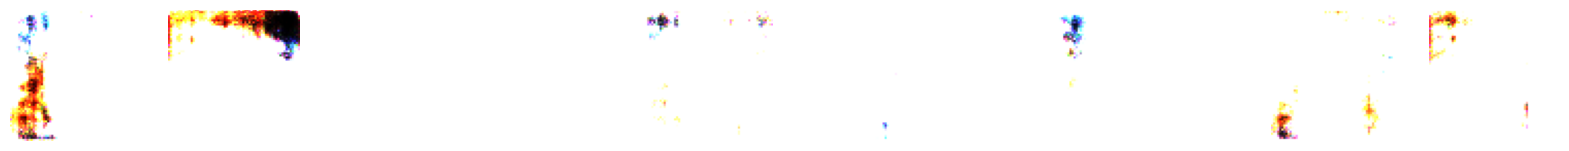

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.036369324..254.34].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0005645752..244.30554].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [9.175377..251.00616].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [7.047455..254.02666].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1723175..249.57246].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.8295975..251.92062].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06467438..253

Saved to ./output/generated_img_1699_label_1.png


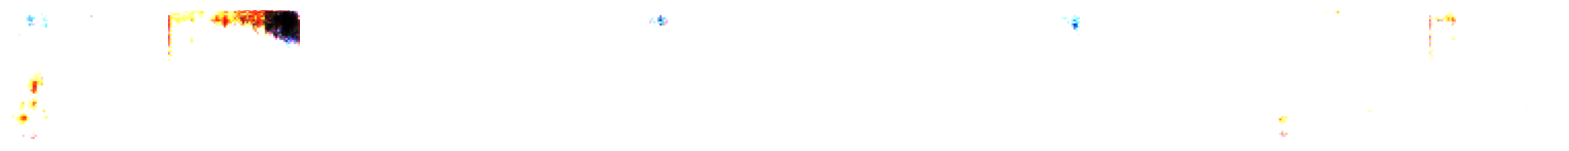

1/1 - 1s - c_loss: -2.0792e+00 - c_wass_loss: -2.5656e+00 - c_gp: 0.0486 - g_loss: -1.5415e+01 - 1s/epoch - 1s/step
Epoch 1701/2000
1/1 - 1s - c_loss: -4.9200e+00 - c_wass_loss: -5.5343e+00 - c_gp: 0.0614 - g_loss: -1.2555e+01 - 678ms/epoch - 678ms/step
Epoch 1702/2000
1/1 - 1s - c_loss: -5.9887e+00 - c_wass_loss: -6.4750e+00 - c_gp: 0.0486 - g_loss: -1.8206e+01 - 551ms/epoch - 551ms/step
Epoch 1703/2000
1/1 - 1s - c_loss: -5.3570e+00 - c_wass_loss: -5.7186e+00 - c_gp: 0.0362 - g_loss: -2.0157e+01 - 583ms/epoch - 583ms/step
Epoch 1704/2000
1/1 - 1s - c_loss: -6.4944e+00 - c_wass_loss: -6.9019e+00 - c_gp: 0.0408 - g_loss: -1.9054e+01 - 586ms/epoch - 586ms/step
Epoch 1705/2000
1/1 - 1s - c_loss: -6.7272e+00 - c_wass_loss: -7.1100e+00 - c_gp: 0.0383 - g_loss: -1.5010e+01 - 676ms/epoch - 676ms/step
Epoch 1706/2000
1/1 - 1s - c_loss: -1.1504e+00 - c_wass_loss: -1.5955e+00 - c_gp: 0.0445 - g_loss: -2.1304e+01 - 590ms/epoch - 590ms/step
Epoch 1707/2000
1/1 - 1s - c_loss: -8.7668e+00 - c_wass_

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14886475..249.3916].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.9032135..254.40225].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.000869751..254.85571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.6184921..252.47653].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1718216..254.5932].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.0730972..253.01053].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.11328888..25

Saved to ./output/generated_img_1799_label_0.png


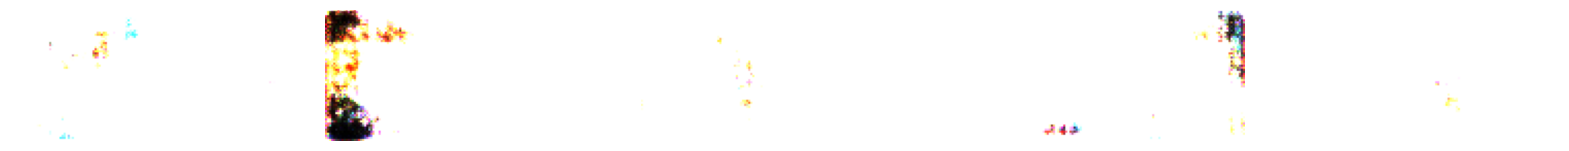

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.79351807..246.93198].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [6.6371994..254.08997].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0070266724..254.5936].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [7.445671..252.94917].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.4474564..254.57303].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [9.179619..253.08876].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.7231064..252

Saved to ./output/generated_img_1799_label_1.png


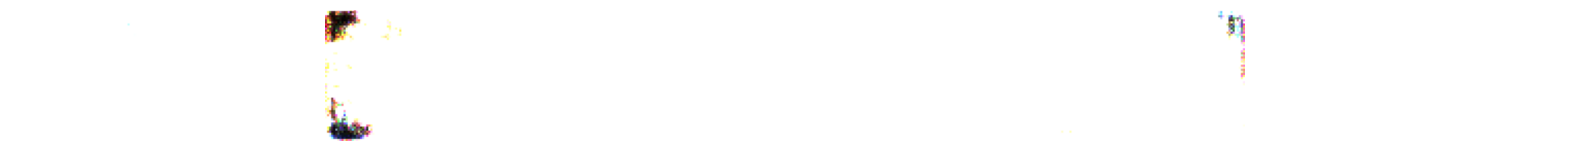

1/1 - 1s - c_loss: -2.4179e+00 - c_wass_loss: -2.9030e+00 - c_gp: 0.0485 - g_loss: -2.9913e+01 - 1s/epoch - 1s/step
Epoch 1801/2000
1/1 - 1s - c_loss: -5.6784e+00 - c_wass_loss: -6.3241e+00 - c_gp: 0.0646 - g_loss: -2.8194e+01 - 681ms/epoch - 681ms/step
Epoch 1802/2000
1/1 - 1s - c_loss: -8.2331e+00 - c_wass_loss: -9.0060e+00 - c_gp: 0.0773 - g_loss: -2.6437e+01 - 627ms/epoch - 627ms/step
Epoch 1803/2000
1/1 - 1s - c_loss: -7.1484e+00 - c_wass_loss: -8.3054e+00 - c_gp: 0.1157 - g_loss: -2.3901e+01 - 632ms/epoch - 632ms/step
Epoch 1804/2000
1/1 - 1s - c_loss: -7.8353e+00 - c_wass_loss: -8.8852e+00 - c_gp: 0.1050 - g_loss: -1.7392e+01 - 614ms/epoch - 614ms/step
Epoch 1805/2000
1/1 - 1s - c_loss: -6.2818e+00 - c_wass_loss: -7.1256e+00 - c_gp: 0.0844 - g_loss: -1.8426e+01 - 536ms/epoch - 536ms/step
Epoch 1806/2000
1/1 - 1s - c_loss: -7.8483e+00 - c_wass_loss: -8.4976e+00 - c_gp: 0.0649 - g_loss: -2.0173e+01 - 581ms/epoch - 581ms/step
Epoch 1807/2000
1/1 - 1s - c_loss: -3.7918e+00 - c_wass_

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.02305603..254.29527].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10799408..254.8064].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8904648..252.77504].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.062942505..253.69348].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031570435..243.80507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.8904648..247.11047].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14038849

Saved to ./output/generated_img_1899_label_0.png


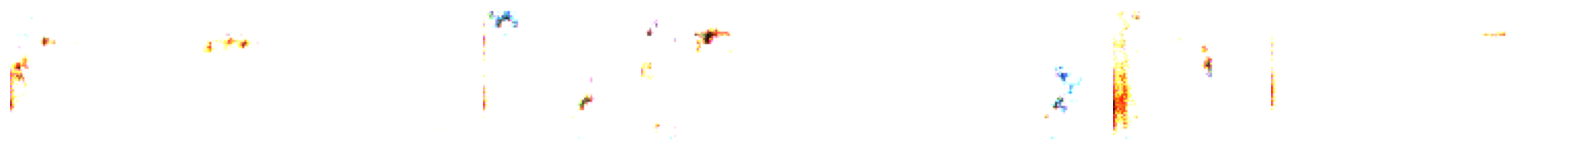

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.16789246..254.40038].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.2458496..254.80295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.9171066..252.17642].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0592041..253.05582].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.27496338..248.90593].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.24646..248.81229].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.0381546..247.

Saved to ./output/generated_img_1899_label_1.png


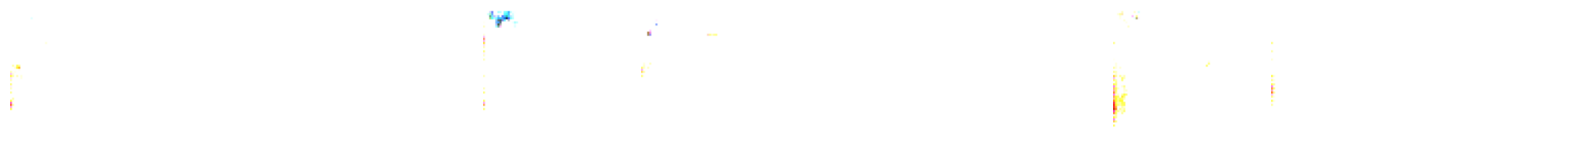

1/1 - 1s - c_loss: -6.0320e+00 - c_wass_loss: -6.3986e+00 - c_gp: 0.0367 - g_loss: -3.2803e+01 - 1s/epoch - 1s/step
Epoch 1901/2000
1/1 - 1s - c_loss: -8.5009e+00 - c_wass_loss: -8.9100e+00 - c_gp: 0.0409 - g_loss: -3.3263e+01 - 641ms/epoch - 641ms/step
Epoch 1902/2000
1/1 - 1s - c_loss: -3.4520e+00 - c_wass_loss: -3.9583e+00 - c_gp: 0.0506 - g_loss: -2.7607e+01 - 822ms/epoch - 822ms/step
Epoch 1903/2000
1/1 - 1s - c_loss: -3.3668e+00 - c_wass_loss: -3.7490e+00 - c_gp: 0.0382 - g_loss: -2.7212e+01 - 610ms/epoch - 610ms/step
Epoch 1904/2000
1/1 - 1s - c_loss: -1.0032e+01 - c_wass_loss: -1.0400e+01 - c_gp: 0.0368 - g_loss: -3.0668e+01 - 595ms/epoch - 595ms/step
Epoch 1905/2000
1/1 - 1s - c_loss: -2.1905e+00 - c_wass_loss: -2.5450e+00 - c_gp: 0.0355 - g_loss: -3.1614e+01 - 573ms/epoch - 573ms/step
Epoch 1906/2000
1/1 - 1s - c_loss: -9.4767e-01 - c_wass_loss: -1.3363e+00 - c_gp: 0.0389 - g_loss: -3.3454e+01 - 584ms/epoch - 584ms/step
Epoch 1907/2000
1/1 - 1s - c_loss: -8.6415e-01 - c_wass_

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12050629..245.66724].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.046279907..254.3655].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.5341644..251.48407].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.19522858..250.38657].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.16164398..226.22797].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.9588699..254.51233].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.023834229

Saved to ./output/generated_img_1999_label_0.png


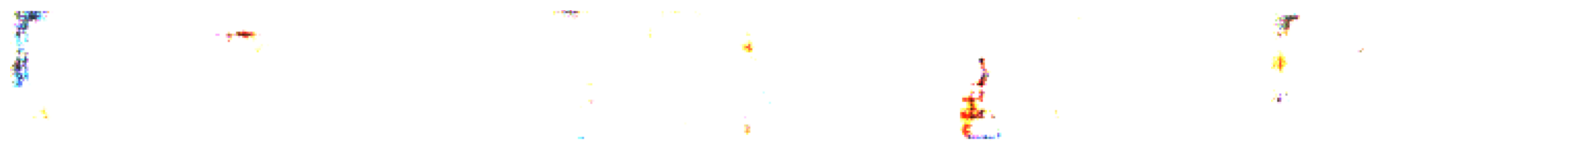

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.15318298..240.11206].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.0032196..254.5163].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [39.118904..249.12444].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.32533264..251.30847].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.777092..234.58987].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.2839966..254.25735].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2213974..254.

Saved to ./output/generated_img_1999_label_1.png


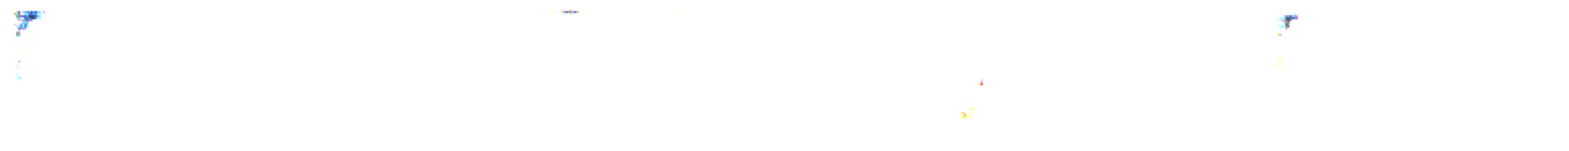

1/1 - 1s - c_loss: 0.3240 - c_wass_loss: -1.4104e-01 - c_gp: 0.0465 - g_loss: -4.3219e+01 - 1s/epoch - 1s/step


In [17]:
history = cgan.fit(
    train,
    epochs=EPOCHS * 100,       # 2000 epochs
    steps_per_epoch=1,         # 1 batch (128 images) per epoch
    verbose=2,                 # one line per epoch (no progress bar)
    callbacks=[
        model_checkpoint_callback,
        tensorboard_callback,
        ImageGenerator(num_img=10, latent_dim=Z_DIM, every_n_epochs=100),
    ],
)

In [19]:
# Save the final models
generator.save("./models/generator")
critic.save("./models/critic")

INFO:tensorflow:Assets written to: ./models/generator\assets


INFO:tensorflow:Assets written to: ./models/generator\assets


INFO:tensorflow:Assets written to: ./models/critic\assets


INFO:tensorflow:Assets written to: ./models/critic\assets


## Generate images

1/1 [==============================] - 0s 37ms/step


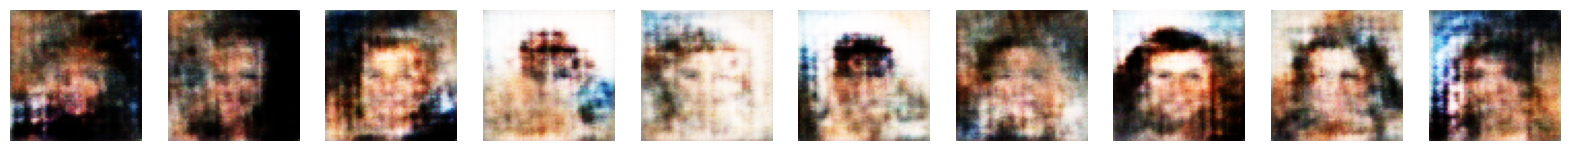

In [20]:
# 0 label
z_sample = np.random.normal(size=(10, Z_DIM))
class_label = np.repeat([[1, 0]], 10, axis=0)
imgs = cgan.generator.predict([z_sample, class_label])
display(imgs, cmap=None)

1/1 [==============================] - 0s 33ms/step


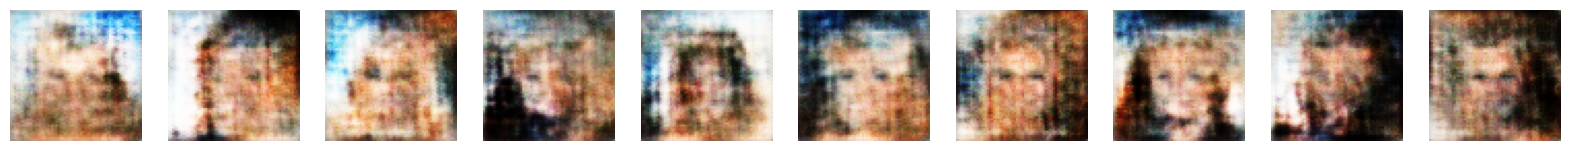

In [21]:
# 1 label
z_sample = np.random.normal(size=(10, Z_DIM))
class_label = np.repeat([[0, 1]], 10, axis=0)
imgs = cgan.generator.predict([z_sample, class_label])
display(imgs, cmap=None)

## Observations and Interpretation

The Conditional WGAN-GP was conditioned on the Blond_Hair attribute from CelebA. Early epochs produced noisy blobs, but by epoch 500 the generator began forming recognizable faces. Around epoch 1000 the two labels started diverging visually, with label 1 samples showing lighter hair tones and label 0 showing darker hair, confirming the model learned the conditioning.

The Wasserstein critic loss trending negative shows the critic learned to separate real from fake, while the generator loss decreasing shows it got better at fooling the critic. The gradient penalty kept training stable throughout as described in the textbook (Foster, 2023).

The model successfully steers output based on the blond hair label. Quality is limited because we used only 1 batch per epoch, so the generator saw limited diversity each step. More steps per epoch or longer training would sharpen the results.

> **AI Note:** CGAN concatenates labels into both generator and critic inputs; WGAN-GP adds a gradient penalty to enforce the Lipschitz constraint instead of weight clipping, stabilizing adversarial training on CelebA faces.